# FashionMNIST Multi-Model Classifier

**Project Overview:**  
This notebook implements and compares 4 neural network architectures on the FashionMNIST dataset:
1. Simple MLP (Multi-Layer Perceptron)
2. Basic CNN (Convolutional Neural Network)
3. Advanced CNN (with dropout and batch normalization)
4. Simplified ResNet (with residual connections)

**Key Features:**
- Data augmentation for improved generalization
- Learning rate scheduling with warmup and cosine annealing
- Comprehensive evaluation with confusion matrices and per-class metrics
- Professional visualization of results

**Author:** Kommal Tariq  
**GitHub:** https://github.com/ktariqq/fashion-mnist-classifier

## 1. Import Libraries and Setup

In [2]:
# Standard library imports
import os
import sys
from pathlib import Path

# Data handling and numerical operations
import numpy as np
import pandas as pd

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# Progress bar
from tqdm.notebook import tqdm

# Add parent directory to path to import custom modules
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(PROJECT_ROOT)
from models.model_architectures import SimpleMLP, BasicCNN, AdvancedCNN, SimplifiedResNet
from utils.helpers import (
    train_epoch, evaluate, plot_training_history, plot_confusion_matrix,
    calculate_metrics, visualize_predictions, LearningRateScheduler
)

# Set theme
sns.set_theme(style="darkgrid")

VIOLET = "#7F00FF"
DEEP_PURPLE = "#2E003E"
PLUM = "#8E4585"
LAVENDER = "#C8A2C8"
HOT_PINK = "#FF007F"
SHOCKING_PINK = "#FF4DCC"
DARK_PINK = "#C2185B"
SOFT_PINK = "#F8BBD0"

sns.set_palette([
    VIOLET,
    HOT_PINK,
    PLUM,
    SHOCKING_PINK,
    LAVENDER,
    DARK_PINK
])

plt.rcParams.update({
    "figure.facecolor": DEEP_PURPLE,
    "axes.facecolor": "#120A1A",
    "axes.edgecolor": VIOLET,
    "axes.labelcolor": LAVENDER,
    "xtick.color": SOFT_PINK,
    "ytick.color": SOFT_PINK,
    "text.color": LAVENDER,
    "grid.color": PLUM,
    "grid.alpha": 0.25,
    "axes.titlecolor": HOT_PINK
})

# Create results directory if it doesn't exist
os.makedirs('../results', exist_ok=True)

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

All libraries imported successfully!
PyTorch version: 2.12.0+cpu
CUDA available: False


## 2. Configuration and Hyperparameters

In [3]:
# Device configuration (use GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Hyperparameters
config = {
    'batch_size': 128,           # Number of samples per batch
    'num_epochs': 20,            # Number of complete passes through dataset
    'learning_rate': 0.001,      # Step size for optimizer
    'weight_decay': 1e-4,        # L2 regularization strength
    'num_workers': 2,            # Number of subprocesses for data loading
    'seed': 42                   # Random seed for reproducibility
}

# Set random seeds for reproducibility
torch.manual_seed(config['seed'])
np.random.seed(config['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed(config['seed'])

# FashionMNIST class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Configuration set!")
print(f"Batch size: {config['batch_size']}")
print(f"Epochs: {config['num_epochs']}")
print(f"Learning rate: {config['learning_rate']}")

Using device: cpu
Configuration set!
Batch size: 128
Epochs: 20
Learning rate: 0.001


## 3. Data Loading and Augmentation

In [4]:
# Data augmentation transforms for training
# Augmentation helps model generalize by creating variations of training images
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),          # Flip image horizontally 50% of time
    transforms.RandomRotation(degrees=10),            # Rotate image up to 10 degrees
    transforms.RandomAffine(degrees=0,                # Random shifts
                           translate=(0.1, 0.1)),
    transforms.ToTensor(),                            # Convert to PyTorch tensor
    transforms.Normalize((0.5,), (0.5,))             # Normalize to [-1, 1] range
])

# Validation/test transform (no augmentation, only normalization)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download and load training dataset
train_dataset = torchvision.datasets.FashionMNIST(
    root='../data',
    train=True,
    download=True,
    transform=train_transform
)

# Download and load test dataset
test_dataset = torchvision.datasets.FashionMNIST(
    root='../data',
    train=False,
    download=True,
    transform=test_transform
)

# Split training data into train and validation (90%-10% split)
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

print(f"Training samples: {len(train_subset)}")
print(f"Validation samples: {len(val_subset)}")
print(f"Test samples: {len(test_dataset)}")

# Create data loaders
# DataLoader handles batching, shuffling, and parallel loading
train_loader = DataLoader(
    train_subset,
    batch_size=config['batch_size'],
    shuffle=True,                      # Shuffle training data each epoch
    num_workers=config['num_workers'],
    pin_memory=True                    # Faster transfer to GPU
)

val_loader = DataLoader(
    val_subset,
    batch_size=config['batch_size'],
    shuffle=False,                     # Don't shuffle validation data
    num_workers=config['num_workers'],
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=config['num_workers'],
    pin_memory=True
)

print("\nData loaders created successfully!")

100%|██████████| 26.4M/26.4M [00:04<00:00, 5.79MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 315kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.23MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 2.88MB/s]

Training samples: 54000
Validation samples: 6000
Test samples: 10000

Data loaders created successfully!


## 4. Visualize Sample Data

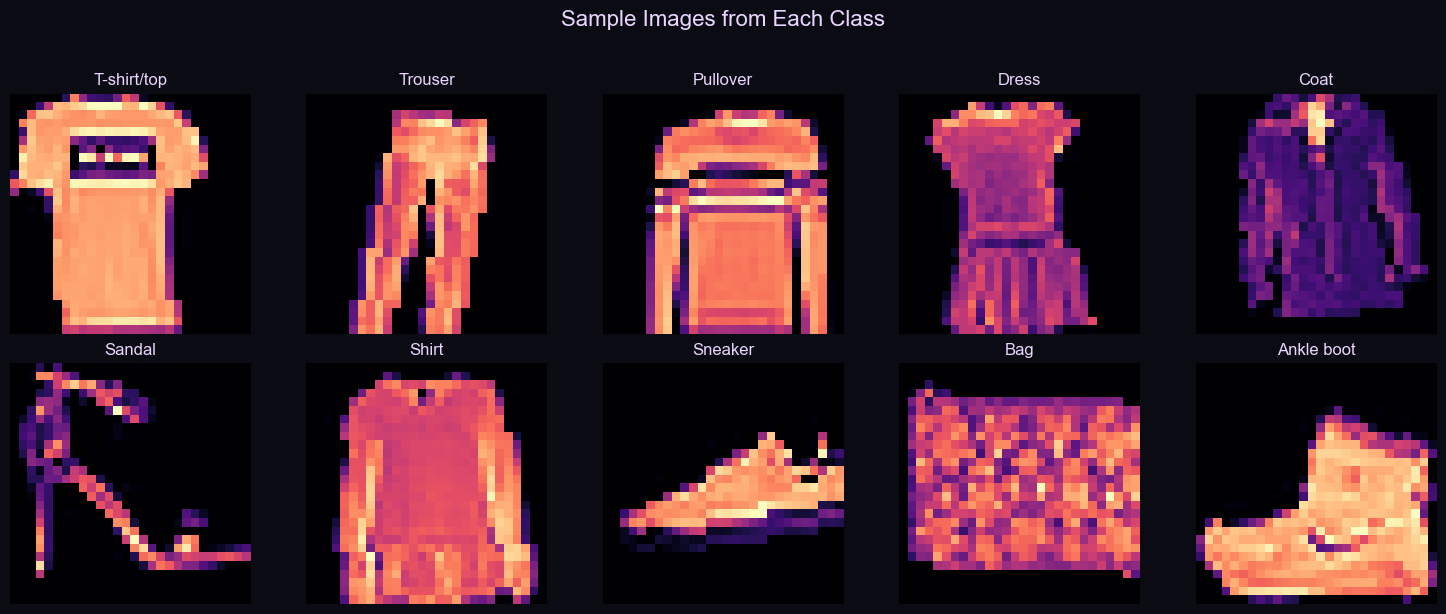

In [5]:
# Display sample images from each class
def show_samples():
    """Display one sample from each class"""
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.ravel()

    # Get one sample from each class
    samples_per_class = {i: None for i in range(10)}

    for img, label in train_dataset:
        if samples_per_class[label] is None:
            samples_per_class[label] = img
        if all(v is not None for v in samples_per_class.values()):
            break

    for i, (label, img) in enumerate(samples_per_class.items()):
        # Denormalize image for display
        img = img.squeeze() * 0.5 + 0.5
        axes[i].imshow(img, cmap='magma')
        axes[i].set_title(f'{class_names[label]}', fontsize=12)
        axes[i].axis('off')

    plt.suptitle('Sample Images from Each Class', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig('../results/sample_images.png', dpi=300, bbox_inches='tight')
    plt.show()

show_samples()

## 5. Define Training Function

In [6]:
def train_model(model, model_name, num_epochs):
    """
    Complete training pipeline for a model.

    Args:
        model: Neural network model
        model_name: Name for logging and saving
        num_epochs: Number of training epochs

    Returns:
        Dictionary containing training history
    """
    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}\n")

    # Move model to device (GPU/CPU)
    model = model.to(device)

    # Loss function (Cross Entropy for multi-class classification)
    criterion = nn.CrossEntropyLoss()

    # Optimizer (Adam with weight decay for regularization)
    optimizer = optim.Adam(
        model.parameters(),
        lr=config['learning_rate'],
        weight_decay=config['weight_decay']
    )

    # Learning rate scheduler
    scheduler = LearningRateScheduler(
        optimizer,
        warmup_epochs=3,
        max_epochs=num_epochs,
        base_lr=config['learning_rate']
    )

    # Track metrics
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'learning_rates': []
    }

    best_val_acc = 0.0

    # Training loop
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 40)

        # Update learning rate
        current_lr = scheduler.step()
        history['learning_rates'].append(current_lr)
        print(f"Learning rate: {current_lr:.6f}")

        # Training phase
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)

        # Validation phase
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

        # Calculate training accuracy
        _, train_acc, _, _ = evaluate(model, train_loader, criterion, device)

        # Store metrics
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Print epoch summary
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
            }, f'../models/{model_name}_best.pth')
            print(f"✓ Best model saved! (Val Acc: {val_acc:.2f}%)")

    print(f"\n{model_name} training completed!")
    print(f"Best validation accuracy: {best_val_acc:.2f}%")

    return history, model

## 6. Train All Models

In [7]:
# Initialize all models
models_dict = {
    'Simple MLP': SimpleMLP(),
    'Basic CNN': BasicCNN(),
    'Advanced CNN': AdvancedCNN(),
    'Simplified ResNet': SimplifiedResNet()
}

# Store training histories and trained models
histories = {}
trained_models = {}

# Train each model
for model_name, model in models_dict.items():
    history, trained_model = train_model(
        model,
        model_name.replace(' ', '_'),
        config['num_epochs']
    )
    histories[model_name] = history
    trained_models[model_name] = trained_model

print("\n" + "="*60)
print("ALL MODELS TRAINED SUCCESSFULLY!")
print("="*60)


Training Simple_MLP


Epoch 1/20
----------------------------------------
Learning rate: 0.000333


Training:   0%|          | 0/422 [00:00<?, ?it/s]C:\Users\ktari\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Training: 100%|██████████| 422/422 [00:36<00:00, 11.62it/s, loss=0.87] 


Train Loss: 0.9707 | Train Acc: 74.69%
Val Loss: 0.6928 | Val Acc: 73.97%
✓ Best model saved! (Val Acc: 73.97%)

Epoch 2/20
----------------------------------------
Learning rate: 0.000667


Training: 100%|██████████| 422/422 [00:36<00:00, 11.70it/s, loss=0.764]


Train Loss: 0.7326 | Train Acc: 77.70%
Val Loss: 0.6215 | Val Acc: 76.92%
✓ Best model saved! (Val Acc: 76.92%)

Epoch 3/20
----------------------------------------
Learning rate: 0.001000


...

Train Loss: 0.1536 | Train Acc: 94.92%
Val Loss: 0.1800 | Val Acc: 93.55%
✓ Best model saved! (Val Acc: 93.55%)

Epoch 19/20
----------------------------------------
Learning rate: 0.000035


Training: 100%|██████████| 422/422 [06:49<00:00,  1.03it/s, loss=0.0454]


Train Loss: 0.1448 | Train Acc: 95.05%
Val Loss: 0.1791 | Val Acc: 93.60%
✓ Best model saved! (Val Acc: 93.60%)

Epoch 20/20
----------------------------------------
Learning rate: 0.000010


Training: 100%|██████████| 422/422 [06:36<00:00,  1.06it/s, loss=0.214] 


Train Loss: 0.1422 | Train Acc: 95.20%
Val Loss: 0.1704 | Val Acc: 93.83%
✓ Best model saved! (Val Acc: 93.83%)

Simplified_ResNet training completed!
Best validation accuracy: 93.83%

ALL MODELS TRAINED SUCCESSFULLY!


## 7. Compare Training Histories

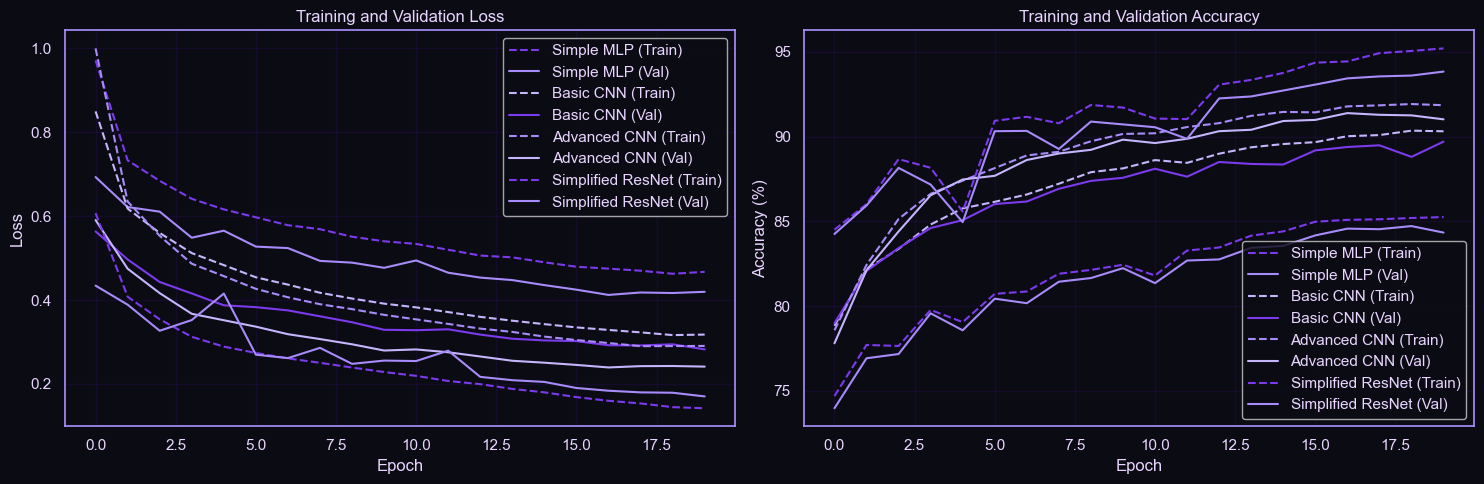

Saved training history to ../results/all_models_training_history.png


In [8]:
# Plot training curves for all models
plot_training_history(
    list(histories.values()),
    list(histories.keys()),
    save_path='../results/all_models_training_history.png'
)

## 8. Evaluate on Test Set

In [9]:
# Evaluate all models on test set
test_results = {}

criterion = nn.CrossEntropyLoss()

print("\nEvaluating models on test set...\n")
print("="*60)

for model_name, model in trained_models.items():
    # Evaluate
    test_loss, test_acc, test_preds, test_labels = evaluate(
        model, test_loader, criterion, device
    )

    # Calculate metrics
    metrics = calculate_metrics(test_labels, test_preds, class_names)

    # Store results
    test_results[model_name] = {
        'accuracy': test_acc,
        'f1_score': metrics['overall_f1'] * 100,
        'predictions': test_preds,
        'labels': test_labels,
        'metrics': metrics
    }

    print(f"{model_name}:")
    print(f"  Test Accuracy: {test_acc:.2f}%")
    print(f"  F1-Score: {metrics['overall_f1']*100:.2f}%")
    print("-" * 60)

print("\nTest evaluation completed!")


Evaluating models on test set...

Simple MLP:
  Test Accuracy: 86.32%
  F1-Score: 86.10%
------------------------------------------------------------


C:\Users\ktari\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Basic CNN:
  Test Accuracy: 90.75%
  F1-Score: 90.67%
------------------------------------------------------------


C:\Users\ktari\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Advanced CNN:
  Test Accuracy: 92.12%
  F1-Score: 92.04%
------------------------------------------------------------


C:\Users\ktari\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Simplified ResNet:
  Test Accuracy: 93.96%
  F1-Score: 93.93%
------------------------------------------------------------

Test evaluation completed!


## 9. Create Results Summary Table

In [10]:
# Create comprehensive results table
results_data = []

for model_name in histories.keys():
    results_data.append({
        'Model': model_name,
        'Final Train Acc (%)': f"{histories[model_name]['train_acc'][-1]:.2f}",
        'Final Val Acc (%)': f"{histories[model_name]['val_acc'][-1]:.2f}",
        'Test Acc (%)': f"{test_results[model_name]['accuracy']:.2f}",
        'F1-Score (%)': f"{test_results[model_name]['f1_score']:.2f}",
        'Best Val Acc (%)': f"{max(histories[model_name]['val_acc']):.2f}"
    })

results_df = pd.DataFrame(results_data)
print("\n" + "="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

# Save to CSV
results_df.to_csv('../results/model_comparison.csv', index=False)
print("\nResults saved to ../results/model_comparison.csv")


FINAL RESULTS SUMMARY
            Model Final Train Acc (%) Final Val Acc (%) Test Acc (%) F1-Score (%) Best Val Acc (%)
       Simple MLP               85.25             84.33        86.32        86.10            84.72
        Basic CNN               90.31             89.70        90.75        90.67            89.70
     Advanced CNN               91.85             91.02        92.12        92.04            91.38
Simplified ResNet               95.20             93.83        93.96        93.93            93.83

Results saved to ../results/model_comparison.csv


## 10. Confusion Matrices

Generating confusion matrix for best model: Simplified ResNet



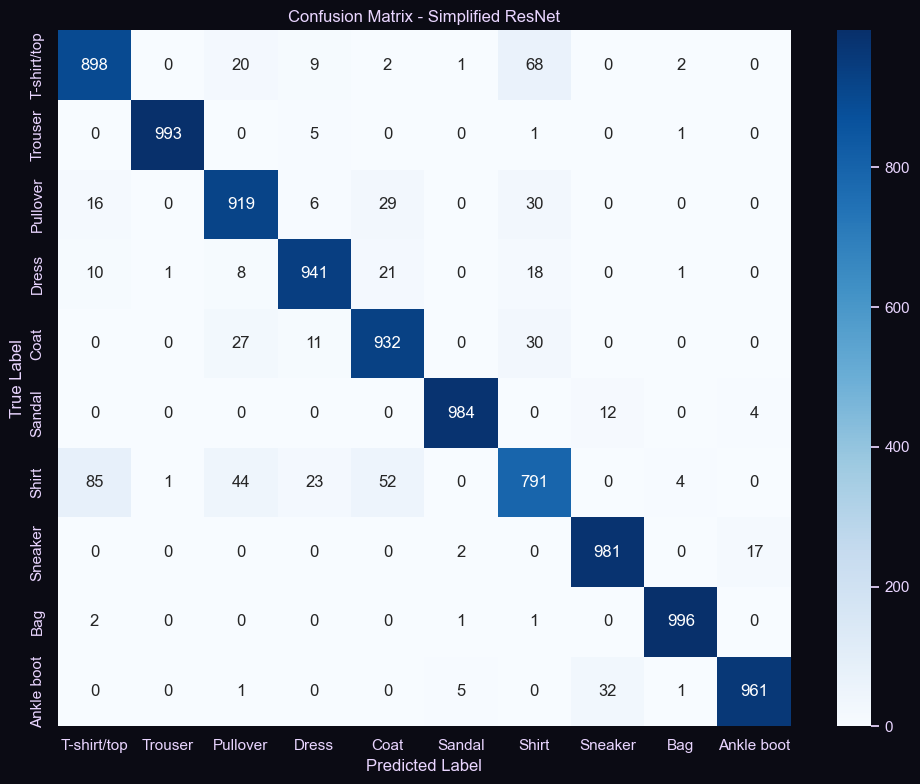

Saved confusion matrix to ../results/Simplified_ResNet_confusion_matrix.png


In [11]:
# Plot confusion matrix for best model
best_model_name = max(test_results.items(), key=lambda x: x[1]['accuracy'])[0]

print(f"Generating confusion matrix for best model: {best_model_name}\n")

plot_confusion_matrix(
    test_results[best_model_name]['labels'],
    test_results[best_model_name]['predictions'],
    class_names,
    best_model_name,
    save_path=f'../results/{best_model_name.replace(" ", "_")}_confusion_matrix.png'
)

## 11. Per-Class Performance Analysis


Per-class performance for Simplified ResNet:

             precision  recall  f1-score  support
T-shirt/top   0.888229   0.898  0.893088   1000.0
Trouser       0.997990   0.993  0.995489   1000.0
Pullover      0.901865   0.919  0.910352   1000.0
Dress         0.945729   0.941  0.943358   1000.0
Coat          0.899614   0.932  0.915521   1000.0
Sandal        0.990937   0.984  0.987456   1000.0
Shirt         0.842386   0.791  0.815884   1000.0
Sneaker       0.957073   0.981  0.968889   1000.0
Bag           0.991045   0.996  0.993516   1000.0
Ankle boot    0.978615   0.961  0.969728   1000.0


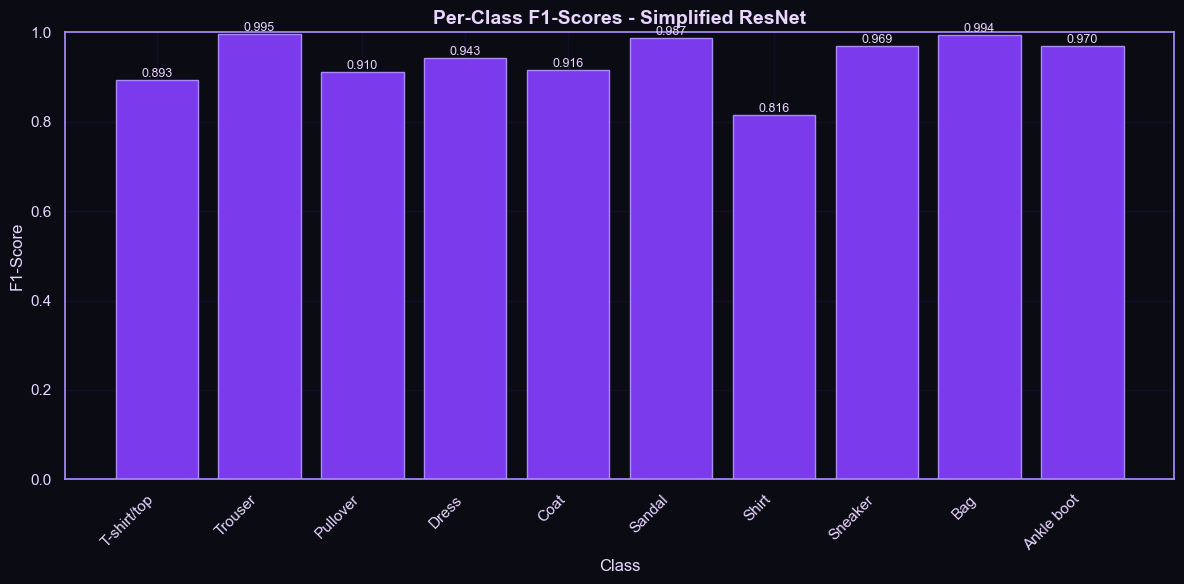

In [12]:
# Detailed per-class metrics for best model
print(f"\nPer-class performance for {best_model_name}:\n")
print(test_results[best_model_name]['metrics']['metrics_df'][['precision', 'recall', 'f1-score', 'support']].head(10))

# Visualize per-class F1 scores
class_metrics = test_results[best_model_name]['metrics']['classification_report']
f1_scores = [class_metrics[cls]['f1-score'] for cls in class_names]

plt.figure(figsize=(12, 6))
bars = plt.bar(class_names, f1_scores, color="#7C3AED", edgecolor="#A78BFA")
plt.xlabel('Class', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.title(f'Per-Class F1-Scores - {best_model_name}', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../results/per_class_f1_scores.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. Visualize Predictions

C:\Users\ktari\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


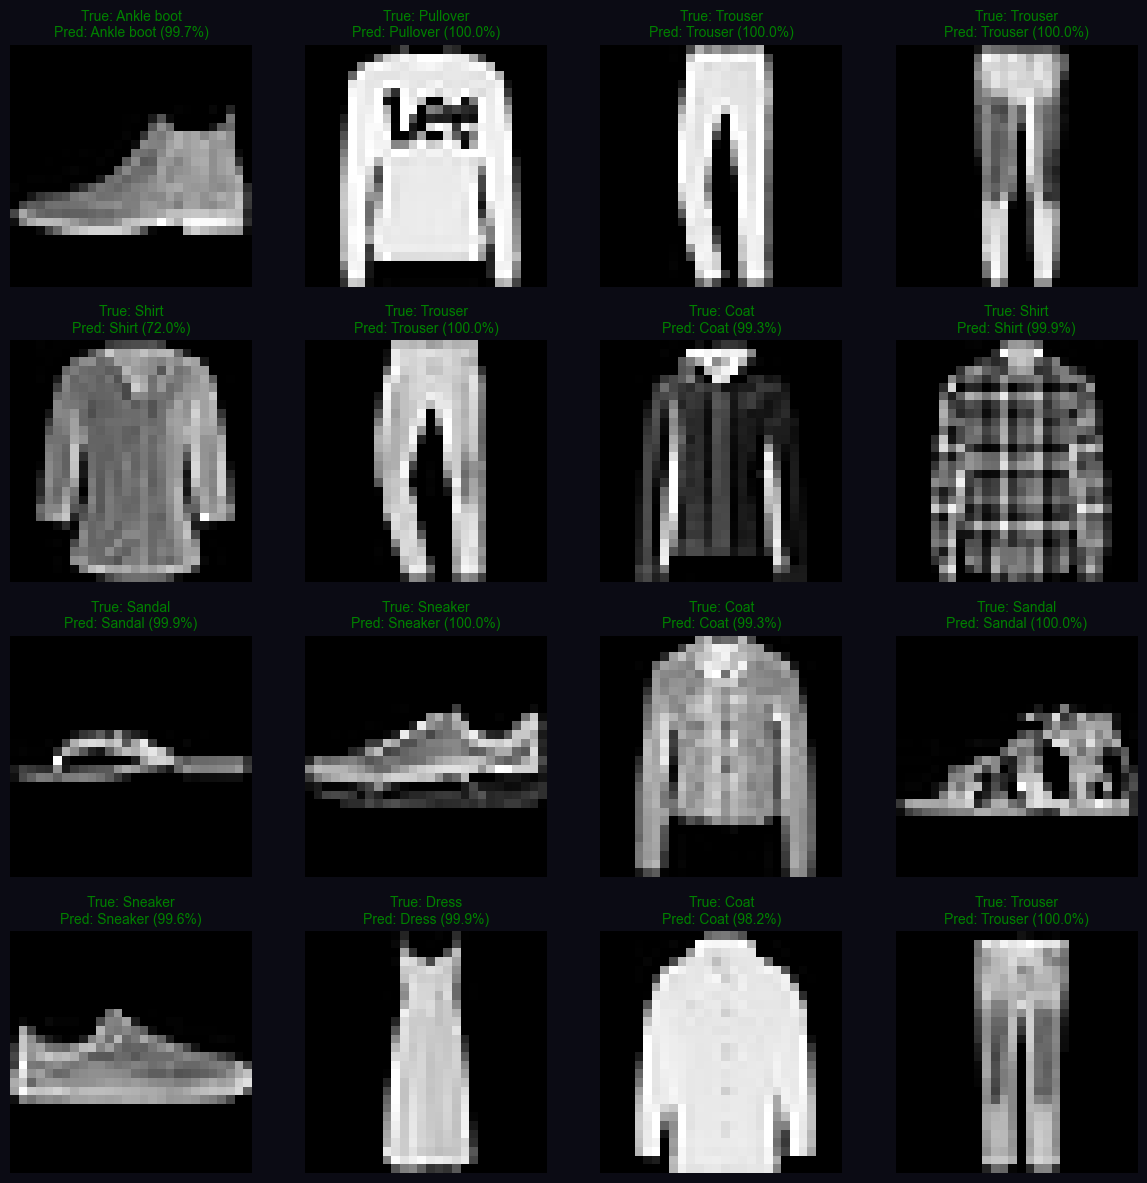

Saved predictions visualization to ../results/sample_predictions.png


In [13]:
# Show predictions from best model
visualize_predictions(
    trained_models[best_model_name],
    test_loader,
    class_names,
    device,
    num_images=16,
    save_path='../results/sample_predictions.png'
)

## 13. Learning Rate Schedule Visualization

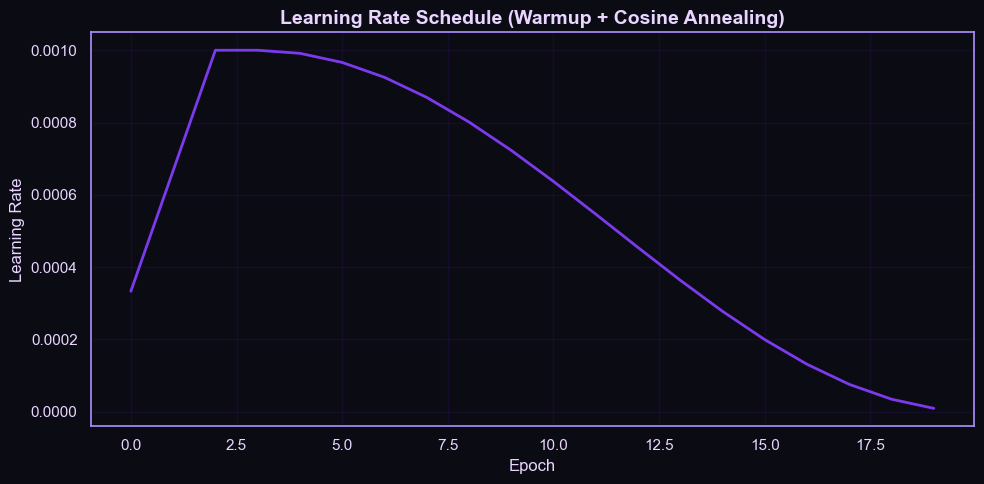

In [14]:
# Plot learning rate schedule for one model
plt.figure(figsize=(10, 5))
plt.plot(histories[best_model_name]['learning_rates'], linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Learning Rate', fontsize=12)
plt.title('Learning Rate Schedule (Warmup + Cosine Annealing)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/learning_rate_schedule.png', dpi=300, bbox_inches='tight')
plt.show()

## 14. Final Summary and Recommendations

In [15]:
print("\n" + "="*80)
print("PROJECT SUMMARY")
print("="*80)

print("\n📊 Dataset: FashionMNIST")
print(f"   - Training samples: {len(train_subset):,}")
print(f"   - Validation samples: {len(val_subset):,}")
print(f"   - Test samples: {len(test_dataset):,}")
print(f"   - Classes: {len(class_names)}")

print("\n🏆 Best Model: " + best_model_name)
print(f"   - Test Accuracy: {test_results[best_model_name]['accuracy']:.2f}%")
print(f"   - F1-Score: {test_results[best_model_name]['f1_score']:.2f}%")

print("\n🔧 Key Techniques Used:")
print("   ✓ Data augmentation (random flips, rotations, affine transforms)")
print("   ✓ Batch normalization for stable training")
print("   ✓ Dropout for regularization")
print("   ✓ Learning rate warmup + cosine annealing")
print("   ✓ Residual connections (ResNet)")
print("   ✓ Adam optimizer with weight decay")

print("\n📁 Generated Artifacts:")
print("   - Training history plots")
print("   - Confusion matrices")
print("   - Per-class F1-score analysis")
print("   - Sample predictions visualization")
print("   - Model comparison CSV")
print("   - Saved model checkpoints (.pth files)")

print("\n💡 Recommendations for Improvement:")
print("   1. Try ensemble methods (combine multiple models)")
print("   2. Experiment with different architectures (EfficientNet, Vision Transformer)")
print("   3. Use techniques like mixup or cutout for data augmentation")
print("   4. Implement k-fold cross-validation")
print("   5. Add test-time augmentation for better accuracy")

print("\n" + "="*80)
print("✅ Notebook execution completed successfully!")
print("="*80)


PROJECT SUMMARY

📊 Dataset: FashionMNIST
   - Training samples: 54,000
   - Validation samples: 6,000
   - Test samples: 10,000
   - Classes: 10

🏆 Best Model: Simplified ResNet
   - Test Accuracy: 93.96%
   - F1-Score: 93.93%

🔧 Key Techniques Used:
   ✓ Data augmentation (random flips, rotations, affine transforms)
   ✓ Batch normalization for stable training
   ✓ Dropout for regularization
   ✓ Learning rate warmup + cosine annealing
   ✓ Residual connections (ResNet)
   ✓ Adam optimizer with weight decay

📁 Generated Artifacts:
   - Training history plots
   - Confusion matrices
   - Per-class F1-score analysis
   - Sample predictions visualization
   - Model comparison CSV
   - Saved model checkpoints (.pth files)

💡 Recommendations for Improvement:
   1. Try ensemble methods (combine multiple models)
   2. Experiment with different architectures (EfficientNet, Vision Transformer)
   3. Use techniques like mixup or cutout for data augmentation
   4. Implement k-fold cross-validat